<a href="https://colab.research.google.com/github/kevinsu-rgb/Senior_Design_TI_Project/blob/main/dualchannel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Version with windowed-merged datasets making 55x1 input, Dense only model.
- data is merged so bins are all mixed up ...
- WINDOW_SIZE = 5, gives the merged-sorted result
- WINDOW_SIZE = 1, gives the concatenated result, no merging due to WINDOW=Frame size


In [21]:
## All Hyper parameters

# Enumeration for each Category, \/\/\/\/\/\/ add new categories here along with data CSV's in folder of same name
#class_data = {0: 'STANDING', 1: 'SITTING', 2: 'LYING', 3: 'FALLING', 4: 'WALKING'}

class_data = {0: 'SITTING', 1: 'FALLING', 2: 'WALKING'}

# Dataset feature formatting
WINDOW_SIZE = 8  # window size of frame data: 1,2,3,4,5,6 ... for example.
WINDOW_CONCATENATE = False  # concatenate each frame within the window or not (ie merge)
WINDOW_SORT = False  # Sort the window data or not (True or False)
MIN_POINTS = 5  # Minimum number of point cloud points for a row to be considered
EQUALISE_DATA_LENGTHS = False  # Set all categories to have the same rows as the fewest

# Heatmap parameters
HEATMAP_ENABLED = True # Enable or disable heatmap generation
HEATMAP_RESOLUTION = (10, 10) # Resolution of the heatmap (height, distance bins)

# Training topics
NUM_EPOCHS = 1200  # TRAINING: number of epochs to run
BATCH_SIZE = 64  # TRAINING: batch size of datasets defining the iterative model update, 64 is OK result.
TEST_SIZE_PERCENT = 20  # split dataset % between test(TEST_SIZE_PERCENT) and train(100-TEST_SIZE_PERCENT)
LEARNING_RATE = .0001  # Learning rate of the optimizer which determines the step size at each iteration while moving toward a minimum of a loss function
F1_SCORE_THRESH = 0.5  # Threshold for converting input into predicted labels for each sample.
# Compute binary f1 score, which is defined as the harmonic mean of precision and recall.

# Enable or disable data visualization
VISUALIZE = True

In [22]:
import torch

torch.manual_seed(42)

import torch.nn as nn
import pandas as pd
from torch.optim import SGD
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import torch.onnx
import sys
from pathlib import Path
import os
import math

print(f"Python version: {sys.version}")
print(f"torch version: {torch.__version__}")
print(f"CUDA version: {torch.version.cuda}")
print(f"CPU instances: {os.cpu_count()}")

# setup module path for helper functions
# from modules.helper_functions import accuracy_fn

##################################################################
# If you have a GPU that supports CUDA, I heavily suggest you    #
# set device to CUDA rather than CPU for significantly increased #
# model training speeds                                          #
##################################################################

if torch.cuda.is_available():
  print(f"GPU: {torch.cuda.get_device_name(0)}, instances:{torch.cuda.device_count()}")
  device = "cuda"
else:
  device = "cpu"

torch.device(device)
print(f"New Device: {device}")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
torch version: 2.9.0+cpu
CUDA version: None
CPU instances: 44
New Device: cpu


### Look for the dataset files and find the classes.

In [23]:
# Setup path to data folder
data_path = Path(os.getcwd() + "/data")
print(data_path)
class_path = Path(f"{data_path}/classes/")

# Find the class names (according to folder structure)
class_names = [f for f in os.listdir(class_path)]

file_names = [f for f in list(class_path.rglob("*.csv"))]
print(f"File names: {file_names}")
print(f"# of Files: {len(file_names)}")


/content/data
File names: [PosixPath('/content/data/classes/SITTING/frames3.csv'), PosixPath('/content/data/classes/SITTING/frames9.csv'), PosixPath('/content/data/classes/SITTING/frames11.csv'), PosixPath('/content/data/classes/SITTING/frames8.csv'), PosixPath('/content/data/classes/SITTING/frames2.csv'), PosixPath('/content/data/classes/SITTING/frames1.csv'), PosixPath('/content/data/classes/SITTING/frames12.csv'), PosixPath('/content/data/classes/SITTING/frames0.csv'), PosixPath('/content/data/classes/FALLING/frames15.csv'), PosixPath('/content/data/classes/FALLING/frames14.csv'), PosixPath('/content/data/classes/FALLING/frames1.csv'), PosixPath('/content/data/classes/FALLING/frames4.csv'), PosixPath('/content/data/classes/WALKING/frames3.csv'), PosixPath('/content/data/classes/WALKING/frames7.csv'), PosixPath('/content/data/classes/WALKING/frames2.csv'), PosixPath('/content/data/classes/WALKING/frames5.csv'), PosixPath('/content/data/classes/WALKING/frames1.csv'), PosixPath('/conte

### Read in the data from the CSV files and concatenate into single dataframe
- Read in the CSV files and concatenate into one large dataset.
- Sort the rows by classification column.  
- separate the classes, and count how many of each classification are present.  
- Visualise the datasets.

In [24]:
import ast
# %%writefile modules/data_setup.py
"""
Read in the data from the CSV files and concatenate into single dataframe
"""

## Read in the CSV files and concatenate into one large dataset.
## Remove collection information columns and add classification column
## Remove any rows with invalid data (not enough points or invalid track ID)
df_csv_append = pd.DataFrame()
heatmap_parser = lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x
for file in file_names:
    df = pd.read_csv(file, encoding='utf-8', engine='python')

    if 'heatmap' in df.columns:
        df['heatmap'] = df['heatmap'].map(
            lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x
        )

    folder_name = os.path.basename(os.path.dirname(file))
    df.insert(0, 'classification', folder_name)

    df_csv_append = pd.concat([df_csv_append, df])

#df_csv_append = df_csv_append.sort_values(by='classification')
#df_csv_append = df_csv_append.reset_index(drop=True) # TODO: fix the indices


Generating visualizations for 3 classes...
Visualizing: SITTING
  Heatmap reshaped to: (32, 32)


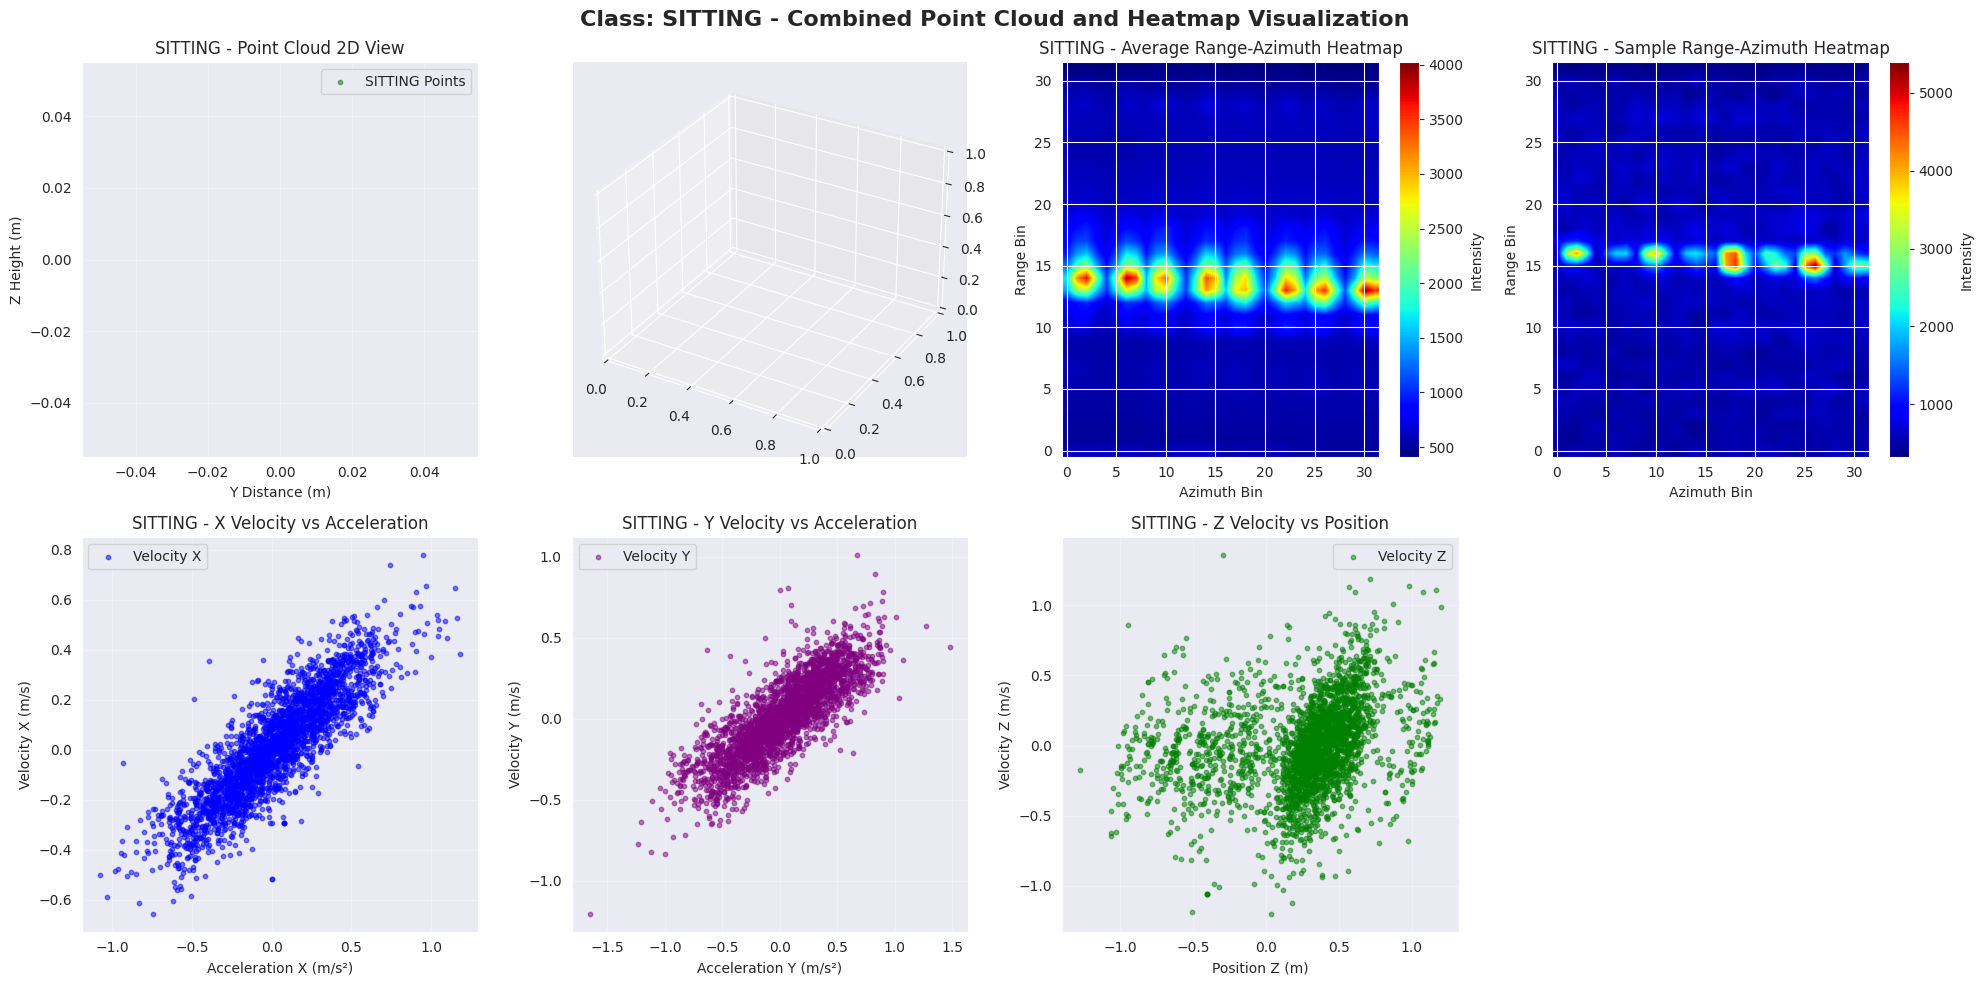


SITTING Statistics:
  Total frames: 2767
  Point cloud points per frame (avg): 0.00
  Velocity X range: -0.655 to 0.778 m/s
  Velocity Y range: -1.205 to 1.010 m/s
  Velocity Z range: -1.199 to 1.356 m/s
  Heatmap original size: 1024
  Heatmap 2D shape: (32, 32)
  Heatmap intensity range: 412.40 to 4020.20

Visualizing: FALLING
  Heatmap reshaped to: (32, 32)


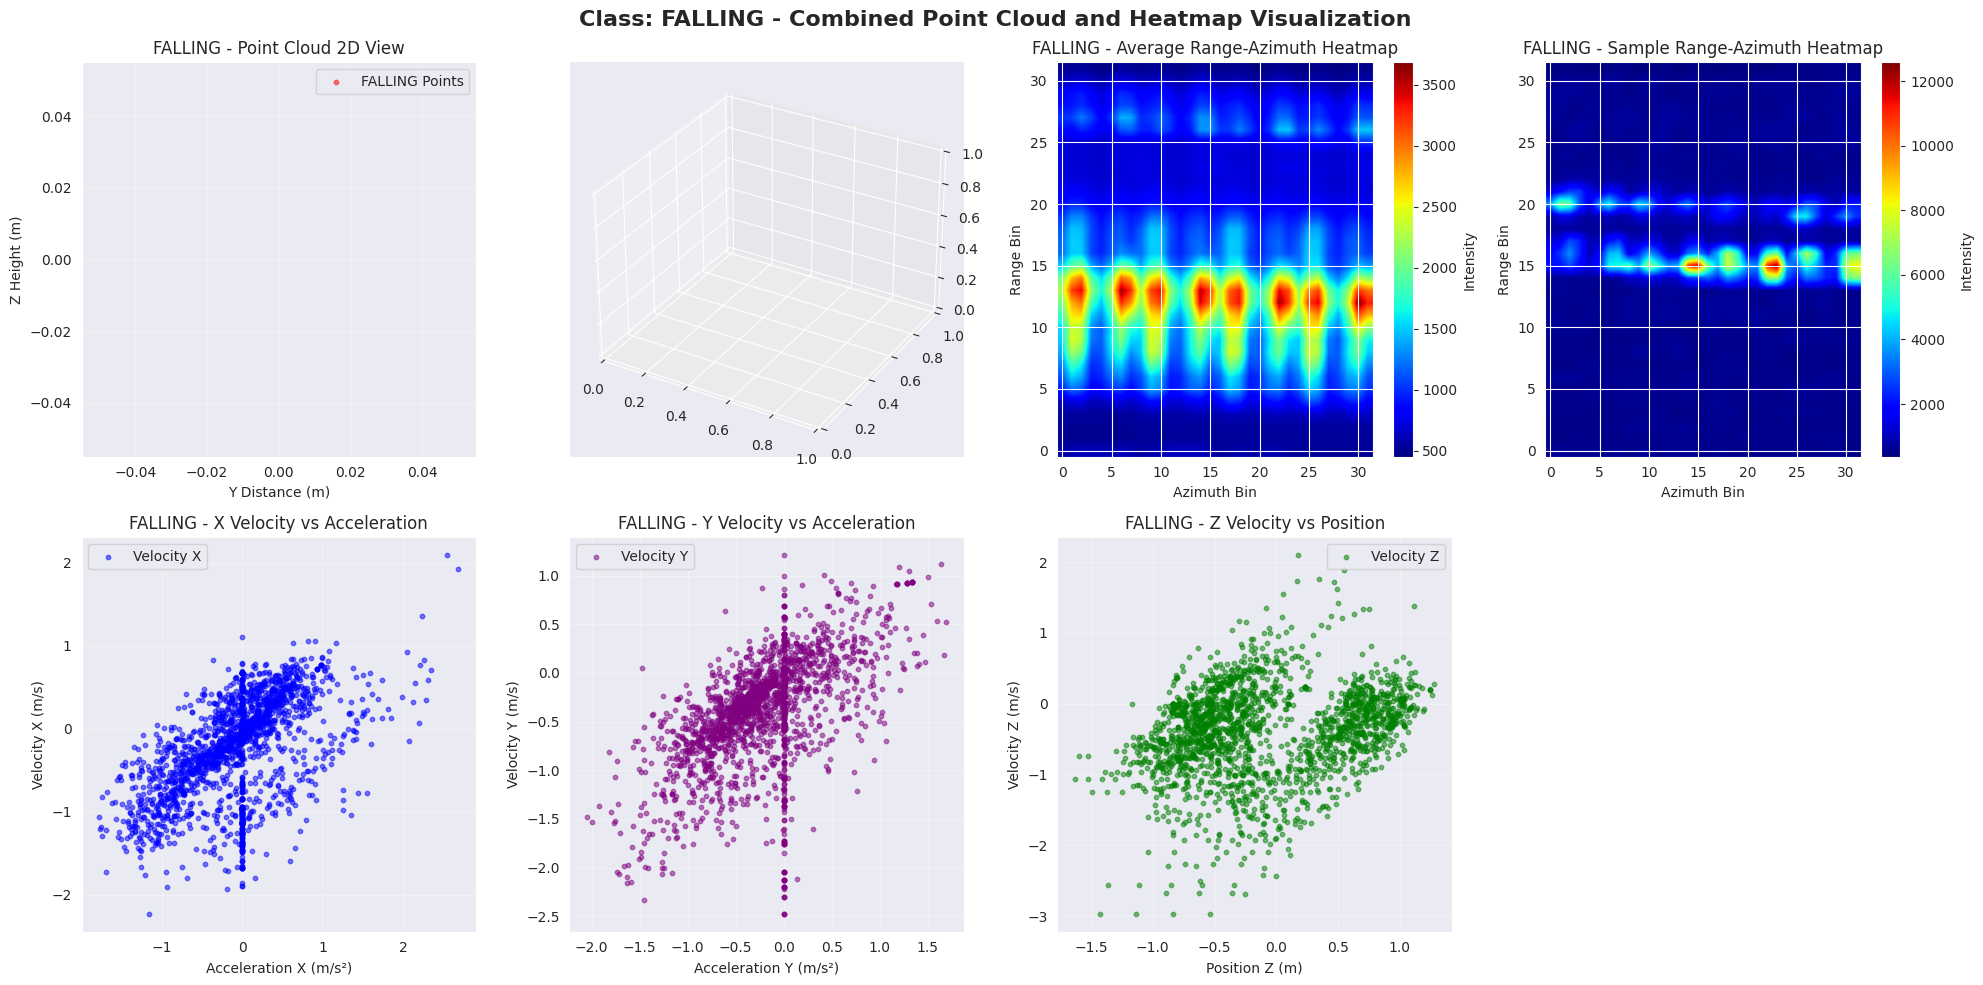


FALLING Statistics:
  Total frames: 2032
  Point cloud points per frame (avg): 0.00
  Velocity X range: -2.230 to 2.090 m/s
  Velocity Y range: -2.475 to 1.210 m/s
  Velocity Z range: -2.968 to 2.097 m/s
  Heatmap original size: 1024
  Heatmap 2D shape: (32, 32)
  Heatmap intensity range: 449.22 to 3685.73

Visualizing: WALKING
  Heatmap reshaped to: (32, 32)


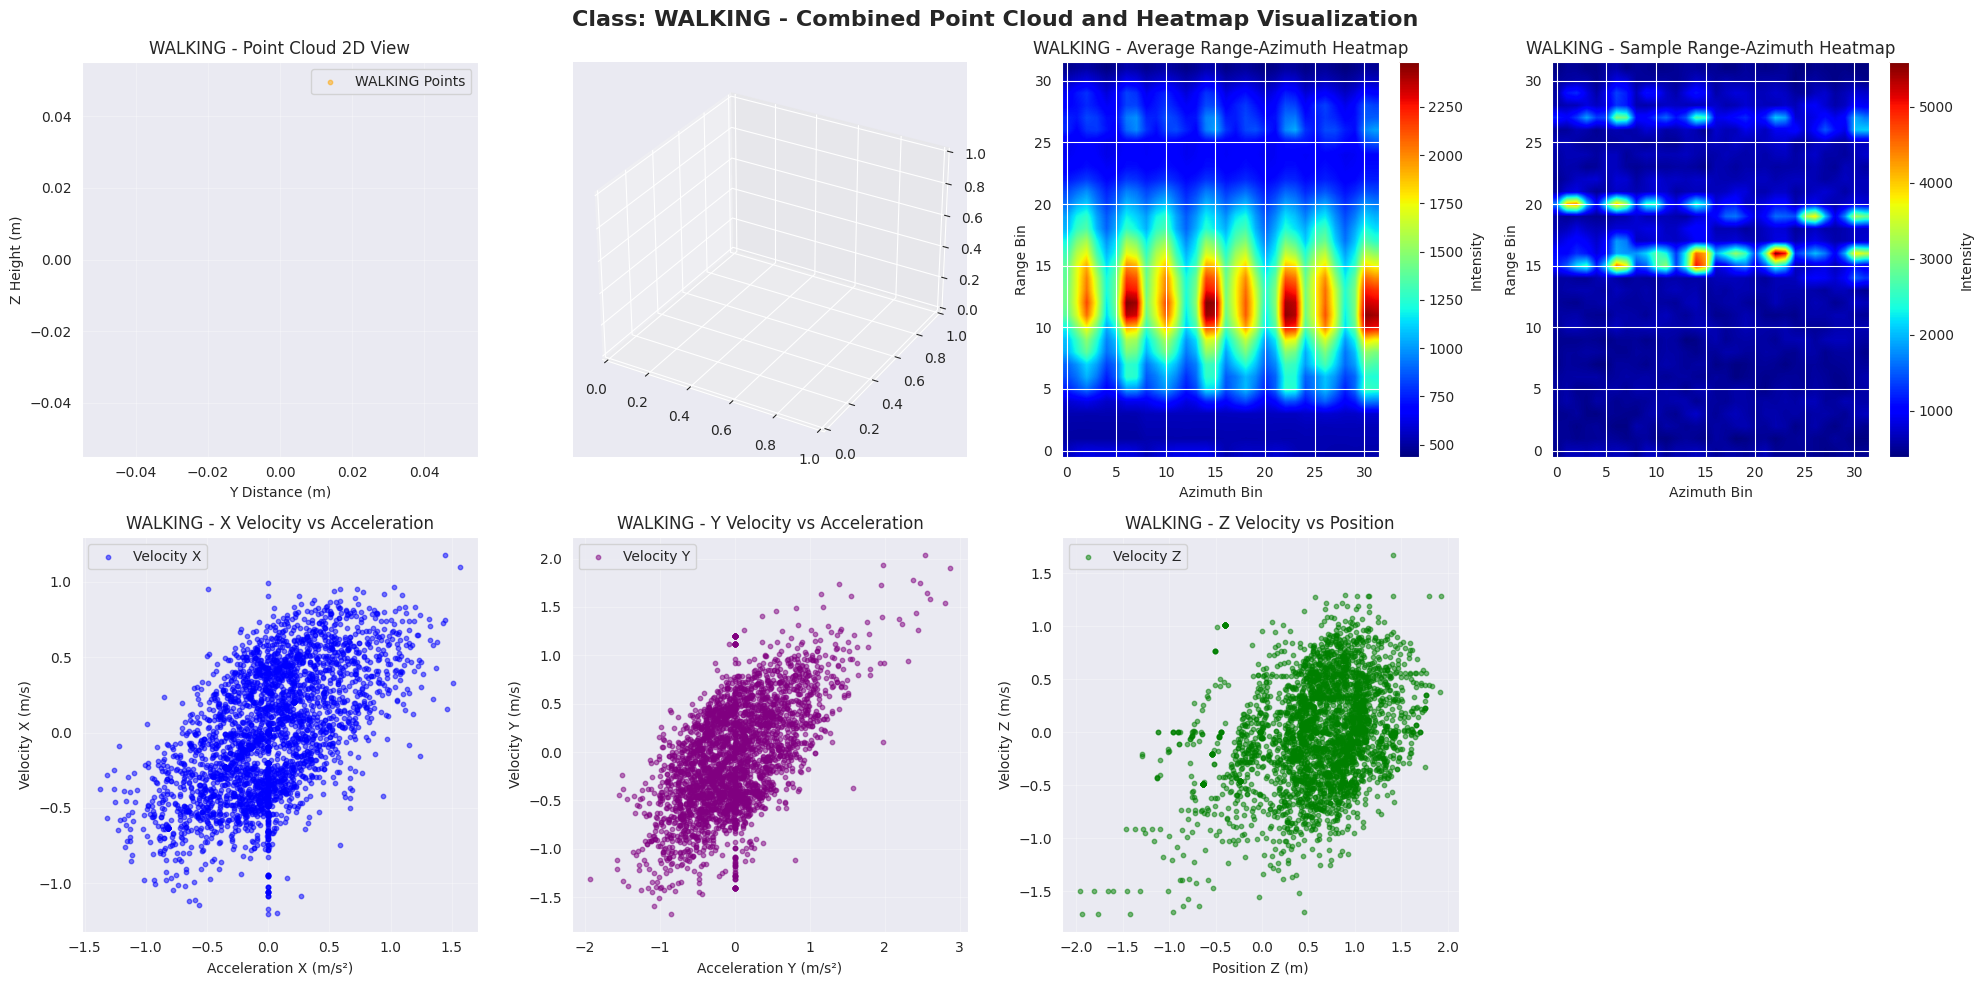


WALKING Statistics:
  Total frames: 3192
  Point cloud points per frame (avg): 0.00
  Velocity X range: -1.202 to 1.177 m/s
  Velocity Y range: -1.673 to 2.034 m/s
  Velocity Z range: -1.712 to 1.671 m/s
  Heatmap original size: 1024
  Heatmap 2D shape: (32, 32)
  Heatmap intensity range: 437.70 to 2480.57

Visualization complete!



In [25]:
## VISUALIZATION CODE

VISUALIZE = True  # Set to False to skip visualization

if VISUALIZE:
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    import seaborn as sns

    # Set style
    sns.set_style("darkgrid")

    # Create separate dataframes for each class
    df_dataList_viz = []
    for i, class_name in class_data.items():
        df_class = df_csv_append[df_csv_append['classification'] == class_name].copy()
        df_class = df_class.drop(['classification'], axis=1)
        df_dataList_viz.append(df_class)

    print(f"\nGenerating visualizations for {len(class_data)} classes...")

    for class_idx, dfFile in enumerate(df_dataList_viz):
        class_name = class_data[class_idx]
        print(f"Visualizing: {class_name}")
        if (len(dfFile) == 0):
          continue

        # Create figure with subplots: 2 rows, 4 columns
        # Row 1: Point cloud 2D, SNR 3D, Heatmap average, Heatmap sample
        # Row 2: Velocity X, Velocity Y, Velocity Z, empty
        fig = plt.figure(figsize=(20, 10))

        # Point Cloud 2D scatter (y vs z)
        ax2d = fig.add_subplot(2, 4, 1)

        # Point Cloud SNR 3D
        axSnr = fig.add_subplot(2, 4, 2, projection='3d')

        # Average Heatmap
        axHeatmapAvg = fig.add_subplot(2, 4, 3)

        # Sample Heatmap
        axHeatmapSample = fig.add_subplot(2, 4, 4)

        # Velocity plots
        axVelocityX = fig.add_subplot(2, 4, 5)
        axVelocityY = fig.add_subplot(2, 4, 6)
        axVelocityZ = fig.add_subplot(2, 4, 7)

        heightPoints = []
        snrPoints = []
        velPointsZ = []
        velPointsY = []
        velPointsX = []

        # Determine MAX_POINTS from columns
        point_cols = [col for col in dfFile.columns if col.startswith('y') and col[1:].isdigit()]
        MAX_POINTS = len(point_cols)

        # Extract point cloud data
        for _, row in dfFile.iterrows():
            for i in range(MAX_POINTS):
                if f'y{i}' in row and f'z{i}' in row and f'snr{i}' in row:
                    y, z, snr = row[f'y{i}'], row[f'z{i}'], row[f'snr{i}']
                    if not (y == 0.0 and z == 0.0 and snr == 0.0):
                        heightPoints.append((y, z))
                        snrPoints.append((y, z, snr))

            # Extract tracker velocity/acceleration data
            if 'posz' in row and 'velz' in row and 'accz' in row:
                velPointsZ.append((row['posz'], row['velz'], row['accz']))
            if 'vely' in row and 'accy' in row:
                velPointsY.append((row['vely'], row['accy']))
            if 'velx' in row and 'accx' in row:
                velPointsX.append((row['velx'], row['accx']))

        # Unzip points
        ysH, zsH = zip(*heightPoints) if heightPoints else ([], [])
        y_snr, z_snr, snr = zip(*snrPoints) if snrPoints else ([], [], [])
        posz, velz, accz = zip(*velPointsZ) if velPointsZ else ([], [], [])
        vely, accy = zip(*velPointsY) if velPointsY else ([], [])
        velx, accx = zip(*velPointsX) if velPointsX else ([], [])

        # Color mapping for classes
        colors = {
            'STANDING': 'yellow',
            'SITTING': 'green',
            'LYING': 'blue',
            'FALLING': 'red',
            'WALKING': 'orange'
        }
        color = colors.get(class_name, 'gray')

        # Plot 2D point cloud
        ax2d.scatter(ysH, zsH, c=color, label=f"{class_name} Points", alpha=0.5, s=10)
        ax2d.set_xlabel("Y Distance (m)")
        ax2d.set_ylabel("Z Height (m)")
        ax2d.set_title(f'{class_name} - Point Cloud 2D View')
        ax2d.legend()
        ax2d.grid(True, alpha=0.3)

        # Plot 3D SNR
        if len(snr) > 0:
            cmap = plt.cm.viridis
            norm = plt.Normalize(vmin=np.min(snr), vmax=np.max(snr))
            for i in range(len(y_snr)):
                line_color = cmap(norm(snr[i]))
                axSnr.plot([y_snr[i], y_snr[i]], [z_snr[i], z_snr[i]],
                          [0, snr[i]], color=line_color, linewidth=2)
            axSnr.set_xlabel("Y (m)")
            axSnr.set_ylabel("Z (m)")
            axSnr.set_zlabel("SNR")
            axSnr.set_title(f'{class_name} - SNR 3D View')

        # Plot velocity graphs
        if velx:
            axVelocityX.scatter(accx, velx, c='blue', label='Velocity X', alpha=0.5, s=10)
            axVelocityX.set_xlabel("Acceleration X (m/s²)")
            axVelocityX.set_ylabel("Velocity X (m/s)")
            axVelocityX.set_title(f'{class_name} - X Velocity vs Acceleration')
            axVelocityX.legend()
            axVelocityX.grid(True, alpha=0.3)

        if vely:
            axVelocityY.scatter(accy, vely, c='purple', label='Velocity Y', alpha=0.5, s=10)
            axVelocityY.set_xlabel("Acceleration Y (m/s²)")
            axVelocityY.set_ylabel("Velocity Y (m/s)")
            axVelocityY.set_title(f'{class_name} - Y Velocity vs Acceleration')
            axVelocityY.legend()
            axVelocityY.grid(True, alpha=0.3)

        if posz:
            axVelocityZ.scatter(posz, velz, c='green', label='Velocity Z', alpha=0.5, s=10)
            axVelocityZ.set_xlabel("Position Z (m)")
            axVelocityZ.set_ylabel("Velocity Z (m/s)")
            axVelocityZ.set_title(f'{class_name} - Z Velocity vs Position')
            axVelocityZ.legend()
            axVelocityZ.grid(True, alpha=0.3)

        if 'heatmap' in dfFile.columns:
            # Parse heatmap data (stored as strings representing lists)
            heatmaps = []
            for idx, row in dfFile.iterrows():
                try:
                    if isinstance(row['heatmap'], str):
                        hm = ast.literal_eval(row['heatmap'])
                    else:
                        hm = row['heatmap']
                    heatmaps.append(np.array(hm))
                except:
                    continue

            if heatmaps:
                # Convert to numpy array
                heatmaps = np.array(heatmaps)

                # Determine heatmap shape - need to reshape 1D to 2D
                # Common radar configurations: 32x32, 64x16, 64x32, etc.
                heatmap_size = heatmaps.shape[1]

                # Try to infer 2D shape - check common dimensions
                possible_shapes = [
                    (32, 32),   # 1024 = 32x32
                    (64, 16),   # 1024 = 64x16
                    (16, 64),   # 1024 = 16x64
                    (64, 32),   # 2048 = 64x32
                    (32, 64),   # 2048 = 32x64
                    (128, 8),   # 1024 = 128x8
                    (8, 128),   # 1024 = 8x128
                ]

                # Find matching shape
                heatmap_2d_shape = None
                for shape in possible_shapes:
                    if shape[0] * shape[1] == heatmap_size:
                        heatmap_2d_shape = shape
                        break

                # If no match found, try square root
                if heatmap_2d_shape is None:
                    sqrt_size = int(np.sqrt(heatmap_size))
                    if sqrt_size * sqrt_size == heatmap_size:
                        heatmap_2d_shape = (sqrt_size, sqrt_size)
                    else:
                        # Default to 64x16 or best guess
                        print(f"Warning: Could not determine heatmap shape for size {heatmap_size}")
                        print(f"Defaulting to (64, {heatmap_size//64})")
                        heatmap_2d_shape = (64, heatmap_size // 64)

                print(f"  Heatmap reshaped to: {heatmap_2d_shape}")

                # Reshape all heatmaps
                heatmaps_2d = heatmaps.reshape(-1, heatmap_2d_shape[0], heatmap_2d_shape[1])

                # Calculate average heatmap
                avg_heatmap = np.mean(heatmaps_2d, axis=0)

                # Plot average heatmap
                im_avg = axHeatmapAvg.imshow(avg_heatmap, aspect='auto', cmap='jet',
                                             origin='lower', interpolation='bilinear')
                axHeatmapAvg.set_xlabel("Azimuth Bin")
                axHeatmapAvg.set_ylabel("Range Bin")
                axHeatmapAvg.set_title(f'{class_name} - Average Range-Azimuth Heatmap')
                plt.colorbar(im_avg, ax=axHeatmapAvg, label='Intensity')

                # Plot sample heatmap (first frame)
                sample_heatmap = heatmaps_2d[0]
                im_sample = axHeatmapSample.imshow(sample_heatmap, aspect='auto', cmap='jet',
                                                   origin='lower', interpolation='bilinear')
                axHeatmapSample.set_xlabel("Azimuth Bin")
                axHeatmapSample.set_ylabel("Range Bin")
                axHeatmapSample.set_title(f'{class_name} - Sample Range-Azimuth Heatmap')
                plt.colorbar(im_sample, ax=axHeatmapSample, label='Intensity')

        plt.suptitle(f'Class: {class_name} - Combined Point Cloud and Heatmap Visualization',
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Print statistics
        print(f"\n{class_name} Statistics:")
        print(f"  Total frames: {len(dfFile)}")
        print(f"  Point cloud points per frame (avg): {len(heightPoints)/len(dfFile):.2f}")
        if velx:
            print(f"  Velocity X range: {min(velx):.3f} to {max(velx):.3f} m/s")
        if vely:
            print(f"  Velocity Y range: {min(vely):.3f} to {max(vely):.3f} m/s")
        if velz:
            print(f"  Velocity Z range: {min(velz):.3f} to {max(velz):.3f} m/s")
        if 'heatmap' in dfFile.columns and len(heatmaps) > 0:
            print(f"  Heatmap original size: {heatmap_size}")
            print(f"  Heatmap 2D shape: {heatmap_2d_shape}")
            print(f"  Heatmap intensity range: {avg_heatmap.min():.2f} to {avg_heatmap.max():.2f}")
        print()

    print("Visualization complete!\n")

### Create feature and label arrays (ie X, y)
1. Convert dataframe data to lists, and concatenate the frame data into windows.
2. Create 2 arrays with X (input), y (output classification)
3. Convert lists to np arrays.
4. Turn our data into tensors for Pytorch.
5. Normalise the feature data so that it is (0 < X < 1)
6. Split our data into training and test sets (train a model on the training set to learn the patterns between `X` and `y` and then evaluate those learned patterns on the test dataset).
    Use `test_size=0.2` (80% training, 20% testing) and the split happens randomly across the data, so from run to run data will look different.


In [26]:
X_pc_list = []
X_hm_list = []
y_list = []

for i, class_name in class_data.items():
    current_df = df_csv_append[df_csv_append['classification'] == class_name].copy()
    current_df = current_df.drop(columns=['classification'])
    #current_df = current_df.reset_index(drop=True)

    if (len(current_df) == 0):
      continue

    print(len(current_df))

    for j in range(0, len(current_df) - WINDOW_SIZE + 1, WINDOW_SIZE):
      window_df = current_df.iloc[j : j + WINDOW_SIZE]

      pc_window = window_df.iloc[:, :-1].values.flatten().tolist()

      hm_window = window_df.iloc[:, -1].values.tolist()

      X_pc_list.append(pc_window)
      X_hm_list.append(hm_window)
      y_list.append(i)


X_pc_np = np.array(X_pc_list, dtype=np.float32).reshape(-1, WINDOW_SIZE , 22)
X_hm_np = np.array(X_hm_list, dtype=np.float32).reshape(-1, WINDOW_SIZE, 32, 32)
y_np = np.array(y_list, dtype=np.int64)
print(f"point cloud shape is {X_pc_np.shape}")
print(f"heatmap shape is {X_hm_np.shape}")
print(f"output shape is {y_np.shape}")

2767
2032
3192
point cloud shape is (998, 8, 22)
heatmap shape is (998, 8, 32, 32)
output shape is (998,)


### Format the data into DataLoaders for use in training
1. convert to dataset format
2. convert to dataloaders with batch size.

In [27]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split # Import train_test_split

# Computing on batches of data, our loss and evaluation metrics will be calculated **per batch** rather than across the whole dataset.
# Need to divide our loss and accuracy values by the number of batches in each dataset's respective dataloader.

# Create the custom datasets, overload the len and getitem classes
class MyDataset(Dataset):
    def __init__(self, pc_data, heatmap_data, labels):
        self.xp = torch.tensor(pc_data, dtype=torch.float32)
        # Heatmaps need a "Channel" dimension for Conv2d: [Batch, 1, H, W]
        # For an item, heatmap_data will be (WINDOW_SIZE, 32, 32)
        # So unsqueeze(1) will make it (WINDOW_SIZE, 1, 32, 32)
        self.xh = torch.tensor(heatmap_data, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.xp[idx], self.xh[idx], self.y[idx]

FEATURE_COUNT = X_pc_np.shape[2]  # Fix: shape is (N, WINDOW_SIZE, FEATURES) so features are at index 2
print(f"Calculated FEATURE_COUNT: {FEATURE_COUNT}")  # Should print 22

# Fix: use StratifiedShuffleSplit to ensure equal class representation and avoid leakage
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE_PERCENT / 100, random_state=42)

for train_idx, test_idx in sss.split(X_pc_np, y_np):
    X_train_pc, X_test_pc = X_pc_np[train_idx], X_pc_np[test_idx]
    X_train_hm, X_test_hm = X_hm_np[train_idx], X_hm_np[test_idx]
    y_train, y_test = y_np[train_idx], y_np[test_idx]

print(f"Split data into train / test:   Train={100 - TEST_SIZE_PERCENT}% Test={TEST_SIZE_PERCENT}%")
print(f"X_train_pc shape: {X_train_pc.shape}, y_train shape: {y_train.shape}")
print(f"X_train_hm shape: {X_train_hm.shape}, y_train shape: {y_train.shape}")
print(f"X_test_pc shape: {X_test_pc.shape}, y_test shape: {y_test.shape}")
print(f"X_test_hm shape: {X_test_hm.shape}, y_test shape: {y_test.shape}")

# Check class distribution in train and test
import collections
print(f"Train class distribution: {collections.Counter(y_train)}")
print(f"Test class distribution:  {collections.Counter(y_test)}")

train_dataset = MyDataset(X_train_pc, X_train_hm, y_train)
test_dataset = MyDataset(X_test_pc, X_test_hm, y_test)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

sample_pc, sample_hm, sample_labels = next(iter(train_dataloader))

print(f"\nPoint Cloud batch shape: {sample_pc.shape}")
print(f"Heatmap batch shape:     {sample_hm.shape}")
print(f"Labels batch shape:      {sample_labels.shape}")


Calculated FEATURE_COUNT: 22
Split data into train / test:   Train=80% Test=20%
X_train_pc shape: (798, 8, 22), y_train shape: (798,)
X_train_hm shape: (798, 8, 32, 32), y_train shape: (798,)
X_test_pc shape: (200, 8, 22), y_test shape: (200,)
X_test_hm shape: (200, 8, 32, 32), y_test shape: (200,)
Train class distribution: Counter({np.int64(2): 319, np.int64(0): 276, np.int64(1): 203})
Test class distribution:  Counter({np.int64(2): 80, np.int64(0): 69, np.int64(1): 51})

Point Cloud batch shape: torch.Size([64, 8, 22])
Heatmap batch shape:     torch.Size([64, 1, 8, 32, 32])
Labels batch shape:      torch.Size([64])


### Define the model
3 fully connected layers with batch normalization before each one

In [28]:
import torch
import torch.nn as nn

class LinearModel(nn.Module):
    '''
    This is modified to have two branches...
    Point Cloud -> Linear -> Fusion -> Linear -> Out
    Heatmap -> Convlayer ->  ^
    '''
    def __init__(self, input_size, output_size):
        super(LinearModel, self).__init__()

        self.pc_branch = nn.Sequential(
            nn.BatchNorm1d(num_features=input_size),
            nn.Linear(in_features=input_size, out_features=64),
            nn.ReLU(),
            nn.BatchNorm1d(num_features=64),
            nn.Linear(in_features=64, out_features=32),
            nn.ReLU()
        )

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten()
        )

        combined_size = 32 + 512

        self.fusion_head = nn.Sequential(
            nn.Linear(combined_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, output_size)
        )

    def forward(self, xp, xh):
        xp = xp.view(xp.size(0), -1)
        out_p = self.pc_branch(xp)

        batch_size, channels, window_size, h, w = xh.shape
        xh_reshaped = xh.view(batch_size * window_size, channels, h, w)
        out_h_per_frame = self.conv_layers(xh_reshaped)
        out_h = out_h_per_frame.view(batch_size, window_size, -1)

        out_h = torch.mean(out_h, dim=1)

        combined = torch.cat((out_p, out_h), dim=1)
        return self.fusion_head(combined)


In [29]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """

    correct = (y_pred.argmax(dim=1) == y_true).sum().item()
    return correct / len(y_true) * 100

### Train the model

EPOCH: 0 | F1: 0.07407
Train loss: 1.39548 | Test loss: 1.40044, Test acc: 13.28%
Distance: 173
EPOCH: 120 | F1: 0.90476
Train loss: 0.70028 | Test loss: 0.72350, Test acc: 77.73%
Distance: 50
EPOCH: 240 | F1: 0.90476
Train loss: 0.59483 | Test loss: 0.62118, Test acc: 83.98%
Distance: 34
EPOCH: 360 | F1: 0.90476
Train loss: 0.52396 | Test loss: 0.56050, Test acc: 85.94%
Distance: 29
EPOCH: 480 | F1: 0.90476
Train loss: 0.47716 | Test loss: 0.50684, Test acc: 85.94%
Distance: 29
EPOCH: 600 | F1: 0.90476
Train loss: 0.41713 | Test loss: 0.45792, Test acc: 88.28%
Distance: 23
EPOCH: 720 | F1: 0.90476
Train loss: 0.36861 | Test loss: 0.41929, Test acc: 89.84%
Distance: 19
EPOCH: 840 | F1: 0.90476
Train loss: 0.34080 | Test loss: 0.38850, Test acc: 89.45%
Distance: 20
EPOCH: 960 | F1: 0.90476
Train loss: 0.30213 | Test loss: 0.35818, Test acc: 91.02%
Distance: 16
EPOCH: 1080 | F1: 0.90476
Train loss: 0.26503 | Test loss: 0.33623, Test acc: 91.02%
Distance: 16
EPOCH: 1199 | F1: 0.90476
Trai

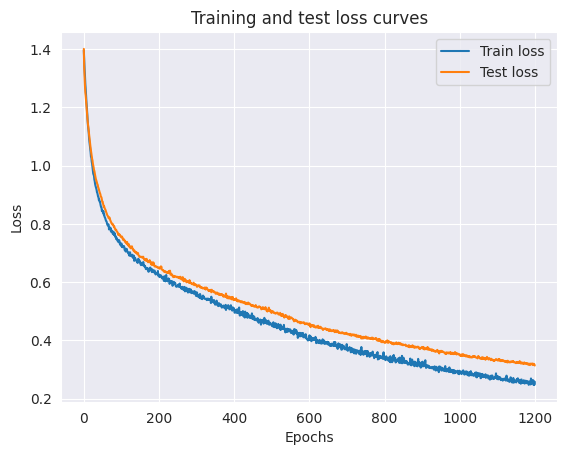

In [20]:
!pip install torchmetrics
import torchmetrics
from torchmetrics.classification import MulticlassF1Score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define model size and send to CPU
# The input_size for the LinearModel should be WINDOW_SIZE * X_pc_np.shape[2]
# because X_pc_np has shape (num_samples, WINDOW_SIZE, num_features_per_frame)
# and in the forward pass, xp is flattened to (batch_size, WINDOW_SIZE * num_features_per_frame).
# The current FEATURE_COUNT was calculated as X_pc_np.shape[1] // WINDOW_SIZE, which is 1.
# This led to input_size = 8 * 1 = 8, while the actual flattened input has 8 * 22 = 176 features.
model_0 = LinearModel(input_size=WINDOW_SIZE * X_pc_np.shape[2], output_size=len(class_data))

model_0.to(device)

loss_fn = nn.CrossEntropyLoss()

# setup the optimizer function
optimizer = SGD(params=model_0.parameters(), lr=LEARNING_RATE)
## Alternative optimizer.
# optimizer = Adam(params=model_0.parameters(), lr = LEARNING_RATE)

# setup F1 score
f1 = MulticlassF1Score(num_classes=len(class_data)).to(device)

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

###############################
# Start the main training loop
###############################
for epoch in range(NUM_EPOCHS):
    ### Training
    train_loss = 0

    for batch, (X_pc, X_hm, y) in enumerate(train_dataloader):
        model_0.train()

        X_pc, X_hm, y = X_pc.to(device), X_hm.to(device), y.to(device)
        y_pred = model_0(X_pc, X_hm)

        y = y.squeeze().long()

        loss = loss_fn(y_pred, y)
        train_loss += loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(train_dataloader)

    ### Testing
    test_loss, test_acc = 0, 0
    model_0.eval()

    all_preds = []
    all_labels = []
    distance = 0

    with torch.inference_mode():
        for X_pc, X_hm, y in test_dataloader:
            X_pc, X_hm, y = X_pc.to(device), X_hm.to(device), y.to(device)

            test_pred = model_0(X_pc, X_hm)

            y = y.squeeze().long()
            loss = loss_fn(test_pred, y)
            test_loss += loss_fn(test_pred, y)

            test_acc += accuracy_fn(y_true=y, y_pred=test_pred)

            predicted_labels = torch.argmax(test_pred, dim=1)

            all_preds.extend(predicted_labels)
            all_labels.extend(y)

            a = predicted_labels.tolist()
            b = y.tolist()

            for i in range(len(a)):
                if a[i] != b[i]:
                    distance += 1

        test_loss /= len(test_dataloader)

        test_acc /= len(test_dataloader)

    if epoch % (NUM_EPOCHS / 10) == 0 or epoch == NUM_EPOCHS - 1:
        print(f"EPOCH: {epoch} | F1: {f1(test_pred, y):.5f}")
        print(f"Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")
        print(f'Distance: {distance}')

    epoch_count.append(epoch)
    train_loss_values.append(train_loss.detach())
    test_loss_values.append(test_loss.detach())

if device == "cuda":
    all_labels = [x.item() for x in all_labels]
    all_preds = [x.item() for x in all_preds]
    train_loss_values = [x.item() for x in train_loss_values]
    test_loss_values = [x.item() for x in test_loss_values]

plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

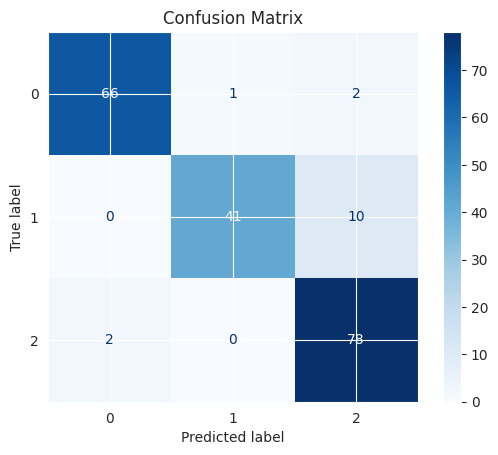

In [30]:
using = {0: 'SITTING', 1: 'FALLING', 2: 'WALKING'}
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=using)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [31]:
#!pip install torchinfo
#from torchinfo import summary
#
#model_0 = LinearModel(input_size=WINDOW_SIZE * FEATURE_COUNT, output_size=len(class_data))
#
## more precise memory requirements - lists all parameters and datatypes to retrieve the bits/bytes used.
#size_model = 0
#for param in model_0.parameters():
#    if param.data.is_floating_point():
#        size_model += param.numel() * torch.finfo(param.data.dtype).bits
#    else:
#        size_model += param.numel() * torch.iinfo(param.data.dtype).bits
#print(f"Model parameters size: {size_model} bits | {size_model / 8e3:.2f} KB")
#
## Overall summary of layers with Torchinfo.
## Provide input_size for both branches of the model
#summary(model_0, input_size=[(1, WINDOW_SIZE * FEATURE_COUNT), (1, 1, WINDOW_SIZE, 32, 32)])

**export the model**

In [32]:
!pip install onnxscript
MODEL_PATH = "model.pth"
print(MODEL_PATH)
#torch.save(model_0.state_dict(), "model.pth")

model_0.eval()
with torch.no_grad():
    # The model expects two inputs: one for point cloud (xp) and one for heatmap (xh)
    # The shapes are derived from the `summary` call: (1, WINDOW_SIZE * FEATURE_COUNT) for xp
    # and (1, 1, WINDOW_SIZE, 32, 32) for xh
    dummy_input_pc = torch.randn(1, WINDOW_SIZE, FEATURE_COUNT).to(device)
    dummy_input_hm = torch.randn(1, 1, WINDOW_SIZE, 32, 32).to(device)
    torch.onnx.export(
        model_0,
        (dummy_input_pc, dummy_input_hm),
        MODEL_PATH,
        opset_version=11,
        input_names=['point_cloud_input', 'heatmap_input'],
        output_names=['output']
    )
#onnx_tool.model_profile(MODEL_PATH, save_profile="my_Linear-profile_relative.txt")

W0409 14:35:33.016000 405 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


model.pth


W0409 14:35:33.306000 405 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0409 14:35:33.307000 405 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0409 14:35:33.308000 405 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0409 14:35:33.309000 405 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `LinearModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `LinearModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:68: adapt: Asserti

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 2 of general pattern rewrite rules.
